In [1]:
from src.callbacks.extras import CountFlopsExtra
from src.utils import module_from_id, get_root, get_ckpt_path
from src.lightning_modules import DSB, Buddy, WPE, GFB, SGMSE
import os
import gc
import torch
from mamba_ssm import Mamba2

os.chdir(get_root())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/an/Documents/Latent-DSB/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/an/Documents/Latent-DSB/.venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:64: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
W0506 15:17:00.165000 187687 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compila

In [2]:
id = "170426112440"
ckpt_filename = f"model-{id}:v0"

ckpt_path = get_ckpt_path(id, ckpt_filename)
DSB_Trained:DSB = module_from_id(id, ckpt_filename)
ckpt = torch.load(ckpt_path, map_location="cpu")
DSB_Trained.ema.load_state_dict(ckpt["ema"])
DSB_Trained.ema.copy_to(DSB_Trained.parameters())
DSB_Trained.to(device)

DSB(
  (model): Mamba2DiffusionModel(
    (down_conv): Conv1d(1, 512, kernel_size=(256,), stride=(16,), padding=(120,), bias=False)
    (up_conv): ConvTranspose1d(512, 1, kernel_size=(256,), stride=(16,), padding=(120,), bias=False)
    (y_embedder): Embedding(2, 512)
    (timestep_embedder): TimestepEmbedder(
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): SiLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
      )
    )
    (blocks): ModuleList(
      (0-9): 10 x Mamba2DiffusionBlock(
        (adaln): AdaLN(
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (scale_proj): Linear(in_features=512, out_features=512, bias=True)
          (shift_proj): Linear(in_features=512, out_features=512, bias=True)
        )
        (mamba_fwd): Mamba2(
          (in_proj): Linear(in_features=512, out_features=2320, bias=False)
          (conv1d): Conv1d(1280, 1280, kernel_size=(4,), stride=(1

In [3]:
BUDDY_100 = Buddy(num_steps=100)
BUDDY_100.to(device)

Loading state dict
dict_keys(['it', 'network', 'optimizer', 'ema', 'args'])
Attempt 1: trying with strict=True


Buddy(
  (network): NCSNppTime(
    (act): SiLU()
    (output_layer): Conv2d(2, 2, kernel_size=(1, 1), stride=(1, 1))
    (pyramid_upsample): Upsample()
    (pyramid_downsample): Downsample()
    (all_modules): ModuleList(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=512, bias=True)
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): Conv2d(2, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ResnetBlockBigGANpp(
        (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (Dense_0): Linear(in_features=512, out_features=128, bias=True)
        (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Dropout_0): Dropout(p=0, inplace=False)
        (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU()
      )
      (5): ResnetBlockBigGANpp(
        (Group

In [4]:
BUDDY_10 = Buddy(num_steps=10)
BUDDY_10.to(device)

Loading state dict
dict_keys(['it', 'network', 'optimizer', 'ema', 'args'])
Attempt 1: trying with strict=True


Buddy(
  (network): NCSNppTime(
    (act): SiLU()
    (output_layer): Conv2d(2, 2, kernel_size=(1, 1), stride=(1, 1))
    (pyramid_upsample): Upsample()
    (pyramid_downsample): Downsample()
    (all_modules): ModuleList(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=512, bias=True)
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): Conv2d(2, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ResnetBlockBigGANpp(
        (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (Dense_0): Linear(in_features=512, out_features=128, bias=True)
        (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Dropout_0): Dropout(p=0, inplace=False)
        (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU()
      )
      (5): ResnetBlockBigGANpp(
        (Group

In [5]:
GFB_Baseline = GFB(task='rir')
GFB_Baseline.to(device)
GFB_Baseline.eval()

GFB(
  (model): STFTbackbone(
    (embedding): RFF_MLP_Block(
      (MLP): ModuleList(
        (0-2): 3 x Linear()
      )
    )
    (embedding_param): RFF_MLP_Block(
      (MLP): ModuleList(
        (0-2): 3 x Linear()
      )
    )
    (downsamplerT): UpDownResample()
    (downsamplerF): UpDownResample()
    (upsamplerT): UpDownResample()
    (upsamplerF): UpDownResample()
    (downs): ModuleList(
      (0): ModuleList(
        (0): ResnetBlock(
          (res_conv): Identity()
          (proj_in): Identity()
          (H): ModuleList(
            (0): Conv2d()
          )
          (affine): ModuleList(
            (0): Linear()
          )
          (gate): ModuleList(
            (0): Linear()
          )
          (norm): ModuleList(
            (0): BiasFreeGroupNorm()
          )
        )
      )
      (1-3): 3 x ModuleList(
        (0): ResnetBlock(
          (res_conv): Conv2d()
          (proj_in): Conv2d()
          (H): ModuleList(
            (0): Conv2d()
          )
  

In [6]:
SGMSE_Baseline = SGMSE()
SGMSE_Baseline.to(device)

Lightning automatically upgraded your loaded checkpoint from v1.6.4 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../Latent-DSB-Data/hf_cache/sgmse_natural_rir_350k.ckpt`


SGMSE(
  (model): ScoreModel(
    (dnn): NCSNpp(
      (act): SiLU()
      (output_layer): Conv2d(4, 2, kernel_size=(1, 1), stride=(1, 1))
      (pyramid_upsample): Upsample()
      (pyramid_downsample): Downsample()
      (all_modules): ModuleList(
        (0): GaussianFourierProjection()
        (1): Linear(in_features=256, out_features=512, bias=True)
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4-5): 2 x ResnetBlockBigGANpp(
          (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
          (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (Dense_0): Linear(in_features=512, out_features=128, bias=True)
          (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (Dropout_0): Dropout(p=0.0, inplace=False)
          (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): Si

In [7]:
WPE_Baseline = WPE()
WPE_Baseline.to(device)

WPE()

In [97]:
2**15

32768

In [8]:
dummy_batch = {
    "audio": torch.randn(1, 1, 2**15, device=device) # Adjust key and shape as needed. 1s Audio as a default.
}

In [9]:
flop_extra_DSB_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10, 
    direction="forward",
    verbose = True
)

flop_extra_DSB_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50, 
    direction="forward",
    verbose = True
)

flop_extra_Buddy_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_Buddy_100 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=100,
    verbose = True,
)

flop_extra_GFB_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_GFB_20 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=20,
    verbose = True,
)

flop_extra_GFB_30 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=30,
    verbose = True,
)

flop_extra_GFB_40 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=40,
    verbose = True,
)

flop_extra_GFB_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50,
    verbose = True,
)

flop_extra_SGMSE_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_SGMSE_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50,
    verbose = True,
)

flop_extra_WPE = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    verbose = True,
)

In [10]:
result_DSB_10 = flop_extra_DSB_10(pl_module=DSB_Trained, batch=dummy_batch, batch_idx=0)


Module                            FLOP    % Total
---------------------------  ---------  ---------
Global                       1629.014B    100.00%
 - aten.convolution            10.737B      0.66%
 - aten.mul                     0.106B      0.01%
 - aten.addmm                 214.861B     13.19%
 - aten.silu                    0.000B      0.00%
 - aten.add                     0.210B      0.01%
 - aten.native_layer_norm       0.524B      0.03%
 - aten.mm                   1402.575B     86.10%
 DSB                         1629.013B    100.00%
  - aten.convolution           10.737B      0.66%
  - aten.mul                    0.105B      0.01%
  - aten.addmm                214.861B     13.19%
  - aten.silu                   0.000B      0.00%
  - aten.add                    0.210B      0.01%
  - aten.native_layer_norm      0.524B      0.03%
  - aten.mm                  1402.575B     86.10%
  DSB.model                  1629.013B    100.00%
   - aten.convolution          10.737B      0.66%


In [11]:
gc.collect()
torch.cuda.empty_cache()

In [12]:
result_DSB_50 = flop_extra_DSB_50(pl_module=DSB_Trained, batch=dummy_batch, batch_idx=0)


Module                            FLOP    % Total
---------------------------  ---------  ---------
Global                       8145.070B    100.00%
 - aten.convolution            53.687B      0.66%
 - aten.mul                     0.528B      0.01%
 - aten.addmm                1074.305B     13.19%
 - aten.silu                    0.000B      0.00%
 - aten.add                     1.052B      0.01%
 - aten.native_layer_norm       2.621B      0.03%
 - aten.mm                   7012.876B     86.10%
 DSB                         8145.064B    100.00%
  - aten.convolution           53.687B      0.66%
  - aten.mul                    0.524B      0.01%
  - aten.addmm               1074.305B     13.19%
  - aten.silu                   0.000B      0.00%
  - aten.add                    1.049B      0.01%
  - aten.native_layer_norm      2.621B      0.03%
  - aten.mm                  7012.876B     86.10%
  DSB.model                  8145.064B    100.00%
   - aten.convolution          53.687B      0.66%


In [13]:
gc.collect()
torch.cuda.empty_cache()

In [14]:
result_BUDDY_10 = flop_extra_Buddy_10(pl_module=BUDDY_10, batch=dummy_batch, batch_idx=0)


Processing WPE


100%|██████████| 10/10 [00:04<00:00,  2.09it/s]

Module                              FLOP    % Total
-------------------------------  -------  ---------
Global                           19.213T    100.00%
 - aten.mul                       0.006T      0.03%
 - aten.add                       0.004T      0.02%
 - aten.add_                      0.001T      0.00%
 - aten.addmm                     0.000T      0.00%
 - aten.silu                      0.009T      0.05%
 - aten.convolution               6.625T     34.48%
 - aten.bmm                       0.048T      0.25%
 - aten.mul_                      0.000T      0.00%
 - aten.convolution_backward     12.519T     65.16%
 NCSNppTime                      13.293T     69.19%
  - aten.mul                      0.006T      0.03%
  - aten.addmm                    0.000T      0.00%
  - aten.silu                     0.009T      0.05%
  - aten.convolution              6.613T     34.42%
  - aten.add_                     0.001T      0.00%
  - aten.add                      0.004T      0.02%
  - aten.bmm

In [15]:
gc.collect()
torch.cuda.empty_cache()

In [16]:
result_BUDDY_100 = flop_extra_Buddy_100(pl_module=BUDDY_100, batch=dummy_batch, batch_idx=0)


Processing WPE


100%|██████████| 100/100 [00:47<00:00,  2.09it/s]

Module                               FLOP    % Total
-------------------------------  --------  ---------
Global                           192.127T    100.00%
 - aten.mul                        0.064T      0.03%
 - aten.add                        0.042T      0.02%
 - aten.add_                       0.007T      0.00%
 - aten.addmm                      0.001T      0.00%
 - aten.silu                       0.093T      0.05%
 - aten.convolution               66.251T     34.48%
 - aten.bmm                        0.478T      0.25%
 - aten.mul_                       0.000T      0.00%
 - aten.convolution_backward     125.191T     65.16%
 NCSNppTime                      132.929T     69.19%
  - aten.mul                       0.056T      0.03%
  - aten.addmm                     0.001T      0.00%
  - aten.silu                      0.093T      0.05%
  - aten.convolution              66.128T     34.42%
  - aten.add_                      0.007T      0.00%
  - aten.add                       0.040T     

In [17]:
gc.collect()
torch.cuda.empty_cache()

In [18]:
result_GFB_10 = flop_extra_GFB_10(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)

Module                               FLOP    % Total
------------------------------  ---------  ---------
Global                          2426.539B    100.00%
 - aten.mul                        1.842B      0.08%
 - aten.add                        1.114B      0.05%
 - aten.mm                         0.299B      0.01%
 - aten.add_                       0.000B      0.00%
 - aten.convolution             2423.285B     99.87%
 STFTbackbone                   2426.537B    100.00%
  - aten.mul                       1.840B      0.08%
  - aten.mm                        0.299B      0.01%
  - aten.add_                      0.000B      0.00%
  - aten.convolution            2423.285B     99.87%
  - aten.add                       1.113B      0.05%
  STFTbackbone.downsamplerF       77.135B      3.18%
   - aten.convolution             77.135B      3.18%
  STFTbackbone.downsamplerT      308.539B     12.72%
   - aten.convolution            308.539B     12.72%
  STFTbackbone.embedding           0.006B     

In [19]:
gc.collect()
torch.cuda.empty_cache()

In [20]:
result_GFB_20 = flop_extra_GFB_20(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)

Module                               FLOP    % Total
------------------------------  ---------  ---------
Global                          5122.694B    100.00%
 - aten.mul                        3.888B      0.08%
 - aten.add                        2.352B      0.05%
 - aten.mm                         0.630B      0.01%
 - aten.add_                       0.001B      0.00%
 - aten.convolution             5115.824B     99.87%
 STFTbackbone                   5122.689B    100.00%
  - aten.mul                       3.885B      0.08%
  - aten.mm                        0.630B      0.01%
  - aten.add_                      0.001B      0.00%
  - aten.convolution            5115.824B     99.87%
  - aten.add                       2.349B      0.05%
  STFTbackbone.downsamplerF      162.840B      3.18%
   - aten.convolution            162.840B      3.18%
  STFTbackbone.downsamplerT      651.361B     12.72%
   - aten.convolution            651.361B     12.72%
  STFTbackbone.embedding           0.012B     

In [21]:
gc.collect()
torch.cuda.empty_cache()

In [22]:
result_GFB_30 = flop_extra_GFB_30(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)

Module                               FLOP    % Total
------------------------------  ---------  ---------
Global                          7818.849B    100.00%
 - aten.mul                        5.934B      0.08%
 - aten.add                        3.589B      0.05%
 - aten.mm                         0.962B      0.01%
 - aten.add_                       0.001B      0.00%
 - aten.convolution             7808.362B     99.87%
 STFTbackbone                   7818.841B    100.00%
  - aten.mul                       5.930B      0.08%
  - aten.mm                        0.962B      0.01%
  - aten.add_                      0.001B      0.00%
  - aten.convolution            7808.362B     99.87%
  - aten.add                       3.585B      0.05%
  STFTbackbone.downsamplerF      248.546B      3.18%
   - aten.convolution            248.546B      3.18%
  STFTbackbone.downsamplerT      994.182B     12.72%
   - aten.convolution            994.182B     12.72%
  STFTbackbone.embedding           0.019B     

In [23]:
gc.collect()
torch.cuda.empty_cache()

In [24]:
result_GFB_40 = flop_extra_GFB_40(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)

Module                             FLOP    % Total
------------------------------  -------  ---------
Global                          10.515T    100.00%
 - aten.mul                      0.008T      0.08%
 - aten.add                      0.005T      0.05%
 - aten.mm                       0.001T      0.01%
 - aten.add_                     0.000T      0.00%
 - aten.convolution             10.501T     99.87%
 STFTbackbone                   10.515T    100.00%
  - aten.mul                     0.008T      0.08%
  - aten.mm                      0.001T      0.01%
  - aten.add_                    0.000T      0.00%
  - aten.convolution            10.501T     99.87%
  - aten.add                     0.005T      0.05%
  STFTbackbone.downsamplerF      0.334T      3.18%
   - aten.convolution            0.334T      3.18%
  STFTbackbone.downsamplerT      1.337T     12.72%
   - aten.convolution            1.337T     12.72%
  STFTbackbone.embedding         0.000T      0.00%
   - aten.mul                  

In [25]:
gc.collect()
torch.cuda.empty_cache()

In [26]:
result_GFB_50 = flop_extra_GFB_50(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)


Module                             FLOP    % Total
------------------------------  -------  ---------
Global                          13.211T    100.00%
 - aten.mul                      0.010T      0.08%
 - aten.add                      0.006T      0.05%
 - aten.mm                       0.002T      0.01%
 - aten.add_                     0.000T      0.00%
 - aten.convolution             13.193T     99.87%
 STFTbackbone                   13.211T    100.00%
  - aten.mul                     0.010T      0.08%
  - aten.mm                      0.002T      0.01%
  - aten.add_                    0.000T      0.00%
  - aten.convolution            13.193T     99.87%
  - aten.add                     0.006T      0.05%
  STFTbackbone.downsamplerF      0.420T      3.18%
   - aten.convolution            0.420T      3.18%
  STFTbackbone.downsamplerT      1.680T     12.72%
   - aten.convolution            1.680T     12.72%
  STFTbackbone.embedding         0.000T      0.00%
   - aten.mul                  

In [27]:
gc.collect()
torch.cuda.empty_cache()

In [28]:
result_SGMSE_10 = flop_extra_SGMSE_10(pl_module=SGMSE_Baseline, batch=dummy_batch, batch_idx=0)


Module                    FLOP    % Total
---------------------  -------  ---------
Global                 13.334T    100.00%
 - aten.mul             0.000T      0.00%
 - aten.add             0.002T      0.02%
 - aten.addmm           0.000T      0.00%
 - aten.silu            0.025T      0.19%
 - aten.convolution    13.288T     99.66%
 - aten.add_            0.002T      0.01%
 - aten.bmm             0.017T      0.12%
 ScoreModel            13.334T    100.00%
  - aten.mul            0.000T      0.00%
  - aten.addmm          0.000T      0.00%
  - aten.silu           0.025T      0.19%
  - aten.convolution   13.288T     99.66%
  - aten.add_           0.002T      0.01%
  - aten.add            0.002T      0.02%
  - aten.bmm            0.017T      0.12%
  ScoreModel.dnn       13.334T    100.00%
   - aten.mul           0.000T      0.00%
   - aten.addmm         0.000T      0.00%
   - aten.silu          0.025T      0.19%
   - aten.convolution  13.288T     99.66%
   - aten.add_          0.002T    

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [30]:
result_SGMSE_50 = flop_extra_SGMSE_50(pl_module=SGMSE_Baseline, batch=dummy_batch, batch_idx=0)


Module                    FLOP    % Total
---------------------  -------  ---------
Global                 66.669T    100.00%
 - aten.mul             0.000T      0.00%
 - aten.add             0.010T      0.02%
 - aten.addmm           0.001T      0.00%
 - aten.silu            0.125T      0.19%
 - aten.convolution    66.440T     99.66%
 - aten.add_            0.010T      0.01%
 - aten.bmm             0.083T      0.12%
 ScoreModel            66.669T    100.00%
  - aten.mul            0.000T      0.00%
  - aten.addmm          0.001T      0.00%
  - aten.silu           0.125T      0.19%
  - aten.convolution   66.440T     99.66%
  - aten.add_           0.010T      0.01%
  - aten.add            0.010T      0.02%
  - aten.bmm            0.083T      0.12%
  ScoreModel.dnn       66.669T    100.00%
   - aten.mul           0.000T      0.00%
   - aten.addmm         0.001T      0.00%
   - aten.silu          0.125T      0.19%
   - aten.convolution  66.440T     99.66%
   - aten.add_          0.010T    

In [31]:
gc.collect()
torch.cuda.empty_cache()

In [32]:
result_WPE = flop_extra_WPE(pl_module=WPE_Baseline, batch=dummy_batch, batch_idx=0)


Module      FLOP    % Total
--------  ------  ---------
Global         0         0%

Dispatcher FLOPs (Table): 0.00 Billion
Hidden Mamba FLOPs (Hooks): 0.00 Billion
Hidden WPE FLOPs (Hooks): 1.20 Billion
True Total: 1.20 Billion



In [33]:
gc.collect()
torch.cuda.empty_cache()

In [34]:
#from mamba_ssm import Mamba2a
#for module in DSB_10.modules():
#    if isinstance(module,Mamba2):
#        print(module.__total_flops__)

In [35]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    DSB_Trained.sample(dummy_batch["audio"], direction="forward", num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                         MambaSplitConv1dScanCombinedFn        41.57%     123.511ms        55.12%     163.768ms     818.842us      99.712ms        32.04%     164.081ms     820.407us           200  
                                           aten::linear         0.44%       1.300ms         8.20%      24.351ms      33.820us       0.000us         0.00%     163.664ms     227.311us           720  
void cutl

In [36]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    BUDDY_10.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

Processing WPE


100%|██████████| 10/10 [00:03<00:00,  3.15it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
autograd::engine::evaluate_function: ConvolutionBack...         0.23%       6.564ms         1.59%      44.909ms      35.362us       0.000us         0.00%     757.733ms     596.640us          1270  
                                   ConvolutionBackward0         0.06%       1.675ms         1.27%      35.962ms      28.316us       0.000us         0.00%     756.027ms     595.297us          1270  
         

In [37]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    GFB_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                      aten::convolution         0.35%       2.403ms         8.27%      57.204ms      32.595us       0.000us         0.00%     415.161ms     236.559us          1755  
                                     aten::_convolution         0.71%       4.910ms         7.92%      54.801ms      31.226us       0.000us         0.00%     415.161ms     236.559us          1755  
         

In [38]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    SGMSE_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::conv2d         0.10%       2.421ms         5.41%     126.070ms      42.881us       0.000us         0.00%        1.540s     523.846us          2940  
                                      aten::convolution         0.21%       4.784ms         5.30%     123.649ms      42.057us       0.000us         0.00%        1.540s     523.846us          2940  
         

In [39]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    WPE_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
               aten::unbind         0.63%      13.848us         1.38%      30.522us      30.522us             1  
               aten::select         0.50%      11.099us         0.75%      16.674us      16.674us             1  
           aten::as_strided         0.38%       8.293us         0.38%       8.293us       4.147us             2  
                   aten::to         0.38%       8.491us        73.76%       1.629ms     407.273us             4  
             aten::_to_copy         1.04%      23.077us        73.38%       1.621ms     540.200us             3  
        aten::empty_strided         1.98%      43.751us         1.98%      43.751us     

In [1]:
# Coordinates
#dsb #[FAD, SI-SDRi, ]
dsb10 = [0.32208, 2.09332, 0.80321]
dsb20 = [0.31766, 2.07953,0.80365]
dsb30 = [0.31202, 2.07074,0.080363]
dsb40 = [0.31007, 2.06529,0.80486]
dsb50 = [0.3055, 2.06041,0.80506]
#Buddy
buddy10 = [0.86144, -8.74615]
buddy50 = [0.30779, -0.035964]
buddy75 = [0.23368,0.70489]
buddy100 = [0.2279, 1.15005]
#gfb
gfb10 = [0.54138, -0.89591]
gfb20 = [0.39837, 0.16218]
gfb30 = [0.36275, -0.02698]
gfb40 = [0.35681, -0.27561]
gfb50 = [0.35594, -0.48099]

wpe = [0.44841, 1.24228]

#Paired baselines
#a2asb
a2asb10 = [0.2717,7.14532]
a2asb20 = [0.26624,7.039]
a2asb30 = [0.26103,6.9927]
a2asb40 = [0.25357, 6.96735]
a2asb50 = [0.25021,6.94675]
#sgmse
sgmse10 = [0.24893,2.27099]
sgmse20 = [0.16987,2.266756]
sgmse30 = [0.16361,2.1847]
sgmse40 = [0.16087,2.09096]
sgmse50 = [0.15921,2.01117]

# GFLOPs sizes
dsb10_size = 2393.74
dsb20_size = dsb10_size * 2
dsb30_size = dsb10_size * 3
dsb40_size = dsb10_size * 4
dsb50_size = 11968.70
#
buddy10_size = 19212.73
buddy50_size = buddy10_size*5
buddy75_size = buddy10_size*7.5
buddy100_size = 192127.31
#
gfb10_size = 2426.54
gfb20_size = 5122.69
gfb30_size = 7818.85
gfb40_size = 10515.00
gfb50_size = 13211.16

wpe_size = 1.20
#Paired baselines
a2asb10_size = dsb10_size
a2asb20_size = dsb20_size
a2asb30_size = dsb30_size
a2asb40_size = dsb40_size
a2asb50_size = dsb50_size

sgmse10_size = 13333.80
sgmse20_size = 13333.80 * 2 
sgmse30_size = 13333.80 * 3
sgmse40_size = 13333.80 * 4
sgmse50_size = 66669.01

# --- Wall Times (milliseconds) ---
dsb_time = [214.18575, 392.86526, 581.3678, 772.5415, 1042.28723]
buddy_time = [2481.45239, 2481.45239*5, 15401.09375,22135.40234]
gfb_time = [314.67224, 608.00391, 923.561, 1246.94312, 1713.99402]
wpe_time = 80.7188
a2asb_time = [214.9979,386.56503,574.6427,764.98145,1031.55676]
sgmse_time = [1253.27856, 2385.75024, 3579.00537, 4773.10547, 6276.24561]

In [2]:
1713.99402/314.67224

5.446918418987325

In [3]:
import wandb

flop_dict = {
    # DSB
    'dsb10_size': 2393.74,
    'dsb20_size': 2393.74 * 2,
    'dsb30_size': 2393.74 * 3,
    'dsb40_size': 2393.74 * 4,
    'dsb50_size': 11968.70,
    
    # BUDDy
    'buddy10_size': 19212.73,
    'buddy50_size': 19212.73*5,
    'buddy75_size': 19212.73*7.5,
    'buddy100_size': 192127.31,
    
    # GFB
    'gfb10_size': 2426.54,
    'gfb20_size': 5122.69,
    'gfb30_size': 7818.85,
    'gfb40_size': 10515.00,
    'gfb50_size': 13211.16,
    
    # WPE
    'wpe_size': 1.20,
    
    # Paired baselines: A^2ASB (Matches DSB sizes)
    'a2asb10_size': 2393.74,
    'a2asb20_size': 2393.74 * 2,
    'a2asb30_size': 2393.74 * 3,
    'a2asb40_size': 2393.74 * 4,
    'a2asb50_size': 11968.70,
    
    # Paired baselines: SGMSE
    'sgmse10_size': 13333.80,
    'sgmse20_size': 13333.80 * 2,
    'sgmse30_size': 13333.80 * 3,
    'sgmse40_size': 13333.80 * 4,
    'sgmse50_size': 66669.01
}

wandb.init(project="baselines",name="TFLOPs")
wandb.log(flop_dict)
wandb.finish()

wandb: Currently logged in as: andnymand (bjornsandjensen-dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


a2asb10_size,▁
a2asb20_size,▁
a2asb30_size,▁
a2asb40_size,▁
a2asb50_size,▁
buddy100_size,▁
buddy10_size,▁
buddy50_size,▁
buddy75_size,▁
dsb10_size,▁
+15,...


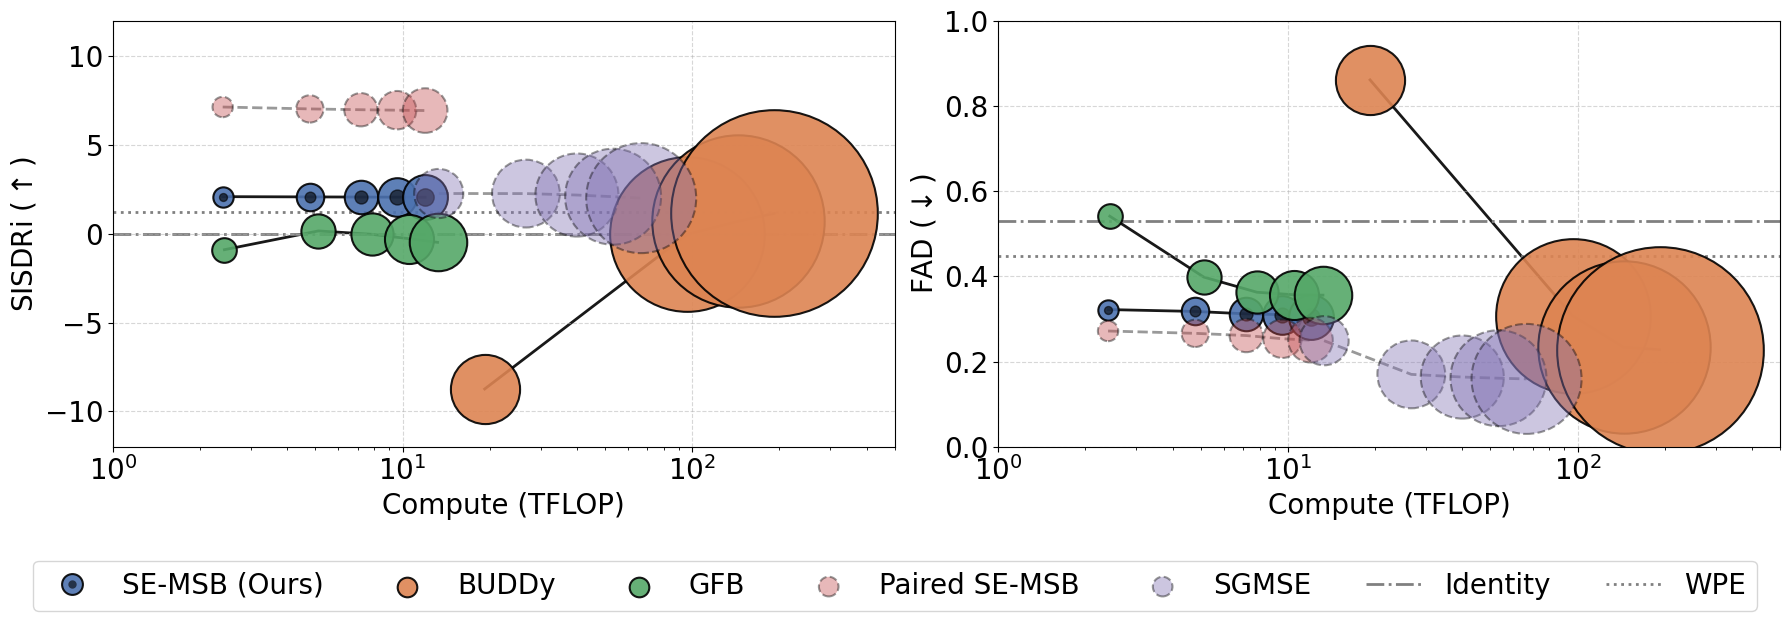

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.legend_handler import HandlerTuple

# --- Global Text Parameter ---
global_font_size = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

time_scale_factor = 1
base_area=0

def calc_time_size(time):
    """Calculates marker area so the *area* scales linearly with Wall Time."""
    desired_radius = (np.sqrt(time) * time_scale_factor)
    return desired_radius ** 2 + base_area

# --- Paper-Friendly Colors ---
c_dsb = '#4C72B0'   
c_buddy = '#DD8452' 
c_gfb = '#55A868'   
c_a2asb = '#C44E52' 
c_sgmse = '#8172B3' 
c_wpe = '#8C8C8C'   

# --- Styling ---
style = {'edgecolors': 'black', 'linewidths': 1.5, 'zorder': 2, 'alpha': 0.9}
style_paired = {'edgecolors': 'black', 'linewidths': 1.5, 'linestyles': '--', 'zorder': 2, 'alpha': 0.4}
style_line = {'linewidth': 2, 'zorder': 1, 'c': 'k', 'alpha': 0.9}
style_line_paired = {'linewidth': 2, 'zorder': 1, 'c': 'k', 'linestyle': '--', 'alpha': 0.4}

# --- Data Structure for Clean Plotting ---
model_families = [
    {
        "name": "SE-MSB", "base_color": c_dsb, "style": style, "line_style": style_line, 
        "our_impl": True, 
        "points": [
            (dsb10, dsb10_size, 10, dsb_time[0]), (dsb20, dsb20_size, 20, dsb_time[1]),
            (dsb30, dsb30_size, 30, dsb_time[2]), (dsb40, dsb40_size, 40, dsb_time[3]), 
            (dsb50, dsb50_size, 50, dsb_time[4])
        ]
    },
    {
        "name": rf"BUDDy", "base_color": c_buddy, "style": style, "line_style": style_line,
        "our_impl": False,
        "points": [
             (buddy10, buddy10_size, 10, buddy_time[0]), (buddy50, buddy50_size, 50, buddy_time[1]), (buddy75, buddy75_size, 75, buddy_time[2]), (buddy100, buddy100_size, 100, buddy_time[3])
        ]
    },
    {
        "name": "GFB", "base_color": c_gfb, "style": style, "line_style": style_line,
        "our_impl": False,
        "points": [
            (gfb10, gfb10_size, 10, gfb_time[0]), (gfb20, gfb20_size, 20, gfb_time[1]),
            (gfb30, gfb30_size, 30, gfb_time[2]), (gfb40, gfb40_size, 40, gfb_time[3]), 
            (gfb50, gfb50_size, 50, gfb_time[4])
        ]
    },
    {
        "name": "Paired SE-MSB", "base_color": c_a2asb, "style": style_paired, "line_style": style_line_paired,
        "our_impl": False, 
        "points": [
            (a2asb10, a2asb10_size, 10, a2asb_time[0]), (a2asb20, a2asb20_size, 20, a2asb_time[1]), 
            (a2asb30, a2asb30_size, 30, a2asb_time[2]), (a2asb40, a2asb40_size, 40, a2asb_time[3]), 
            (a2asb50, a2asb50_size, 50, a2asb_time[4])
        ]
    },
    {
        "name": "SGMSE", "base_color": c_sgmse, "style": style_paired, "line_style": style_line_paired,
        "our_impl": False,
        "points": [
            (sgmse10, sgmse10_size, 10, sgmse_time[0]), (sgmse20, sgmse20_size, 20, sgmse_time[1]),
            (sgmse30, sgmse30_size, 30, sgmse_time[2]), (sgmse40, sgmse40_size, 40, sgmse_time[3]), 
            (sgmse50, sgmse50_size, 50, sgmse_time[4])
        ]
    }
]

# --- Plotting Engine ---
for family in model_families:
    pts = family["points"]
    
    xs_tflops = [p[1] / 1000.0 for p in pts]
    ys_fad = [p[0][0] for p in pts]
    ys_sisdri = [p[0][1] for p in pts]
    
    # Plot trajectory lines
    ax1.plot(xs_tflops, ys_sisdri, **family["line_style"])
    ax2.plot(xs_tflops, ys_fad, **family["line_style"])
    
    # Extract alpha and zorder from the style dict
    current_alpha = family["style"].get("alpha", 1.0)
    current_zorder = family["style"].get("zorder", 2)
    
    # Plot individual bubbles
    for i, (coord, flops, step, wall_time) in enumerate(pts):
        lbl = family["name"] if i == len(pts) - 1 else None
        m_size = calc_time_size(wall_time)
        flops_tflops = flops / 1000.0
        
        # ax1: TFLOPs vs SISDRi
        ax1.scatter(flops_tflops, coord[1], s=m_size, color=family["base_color"], label=lbl, **family["style"])
        if family.get("our_impl", False):
            # FIX: Z-order matches the parent bubble perfectly to prevent floating dots
            ax1.scatter(flops_tflops, coord[1], s=m_size * 0.15, color='k', alpha=0.6, zorder=current_zorder)
        
        # ax2: TFLOPs vs FAD
        ax2.scatter(flops_tflops, coord[0], s=m_size, color=family["base_color"], label=lbl, **family["style"])
        if family.get("our_impl", False):
            # FIX: Z-order matches the parent bubble perfectly
            ax2.scatter(flops_tflops, coord[0], s=m_size * 0.15, color='k', alpha=0.6, zorder=current_zorder)

## --- Plot WPE ---
#wpe_m_size = calc_time_size(wpe_time)
#wpe_tflops = wpe_size / 1000.0
#
## Scatter for WPE
#ax1.scatter(wpe_tflops, wpe[1], s=wpe_m_size, color=c_wpe, label="WPE", **style)
#ax2.scatter(wpe_tflops, wpe[0], s=wpe_m_size, color=c_wpe, label="WPE", **style) 
#
## Annotations for WPE
#ax1.annotate("WPE", xy=(wpe_tflops, wpe[1]), xytext=(15, 20), textcoords='offset points',
#             arrowprops=dict(arrowstyle="->", color='black', lw=1, shrinkA=0, shrinkB=5),
#             fontsize=global_font_size, fontweight='bold', zorder=3, ha='center')
#ax2.annotate("WPE", xy=(wpe_tflops, wpe[0]), xytext=(15, 20), textcoords='offset points',
#             arrowprops=dict(arrowstyle="->", color='black', lw=1, shrinkA=0, shrinkB=5),
#             fontsize=global_font_size, fontweight='bold', zorder=3, ha='center')

# --- Plot Identity Baselines ---
identity_style = {'color': 'gray', 'linestyle': '-.', 'linewidth': 2, 'alpha': 1, 'zorder': 1}
ax1.axhline(y=0.00, label="Identity", **identity_style)
ax2.axhline(y=0.53, **identity_style)
# --- Plot Identity Baselines ---
wpe_style = {'color': 'gray', 'linestyle': ':', 'linewidth': 2, 'alpha': 1, 'zorder': 1}
ax1.axhline(y=wpe[1], label="WPE", **wpe_style)
ax2.axhline(y=wpe[0], **wpe_style)

# --- Final Layout Adjustments ---
# Subplot 1: SISDRi
ax1.set_ylabel(r"SISDRi $(\uparrow)$", fontsize=global_font_size)
ax1.set_xlabel("Compute (TFLOP)", fontsize=global_font_size)
ax1.set_xscale('log')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.tick_params(axis='both', which='major', labelsize=global_font_size)

# Subplot 2: FAD
ax2.set_ylabel(r"FAD $(\downarrow)$", fontsize=global_font_size)
ax2.set_xlabel("Compute (TFLOP)", fontsize=global_font_size)
ax2.set_xscale('log')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.tick_params(axis='both', which='major', labelsize=global_font_size)

ax1.set_xlim(1, 500)
ax1.set_ylim(-12, 12)
ax2.set_xlim(1, 500)
ax2.set_ylim(0, 1)

# --- Legend Modification ---
handles, labels = ax1.get_legend_handles_labels()

# Intercept the SE-DSB handle to add the internal dot representation
if "SE-MSB" in labels:
    idx = labels.index("SE-MSB")
    
    # Create a proxy for the background bubble (color='none' removes hidden bounding boxes)
    proxy_main = plt.Line2D([0], [0], marker='o', color='none', 
                            markerfacecolor=c_dsb, markeredgecolor='black', 
                            markeredgewidth=1.5, markersize=15, 
                            linestyle='None', alpha=0.9)
    
    # Create a proxy for the solid inner circle (markeredgecolor='none' removes the weird white ring)
    proxy_dot = plt.Line2D([0], [0], marker='o', color='none', 
                           markerfacecolor='k', markeredgecolor='none', 
                           markersize=6, linestyle='None', alpha=0.6)
    
    # Combine them into a single entry
    handles[idx] = (proxy_main, proxy_dot)
    labels[idx] = "SE-MSB (Ours)"

# Use ndivide=1 to force the tuple elements to share the same center
leg = fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=7, 
                 fontsize=global_font_size, 
                 handler_map={tuple: HandlerTuple(ndivide=1)})

# Standardize legend marker sizes
for handle in leg.legend_handles:
    if not isinstance(handle, tuple) and hasattr(handle, 'set_sizes'):
        handle.set_sizes([200])

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()